In [1]:
# ── CELL 1: Imports ───────────────────────────────────────────
import sys
sys.path.append('../Scr')
from cleaning_functions import *
from pathlib import Path
 
DATA_CLEAN = Path("../Data/Clean")
DATA_CLEAN.mkdir(parents=True, exist_ok=True)

In [2]:
# ── 2: Load config ───────────────────────────────────────
config = load_config()

In [ ]:
# ── 3: Dataset 1 — rivers_with_countries ────────────────
rivers = load_rivers(config["input_data"]["file1"])
rivers_with_countries = assign_countries_to_rivers(rivers)
 
# Optional: check the map
plot_rivers_known_unknown(rivers_with_countries)
 
# Save
rivers_with_countries.to_parquet(config["output_data"]["file1"])
print("✅ Dataset 1 saved")

Unknown after 10m join: 10795
Buffer 0.1° → 20 unknown remaining
Buffer 0.25° → 4 unknown remaining
Buffer 0.5° → 1 unknown remaining


In [ ]:
# ── 4: Dataset 2 — plastic_adrift ───────────────────────
plastic_adrift = load_plastic_adrift(config["input_data"]["file2"])
plastic_adrift.write_parquet(config["output_data"]["file2"])
print("✅ Dataset 2 saved")

lng range after fix: -179 to 180
✅ Dataset 2 saved


In [ ]:
# ── 5: Dataset 3 — marine_microplastics ─────────────────
marine_microplastics = load_marine_microplastics(config["input_data"]["file3"])
marine_microplastics.write_parquet(config["output_data"]["file3"])
print("✅ Dataset 3 saved")

Shape: (22530, 14)
sample_date nulls: 0
✅ Dataset 3 saved


Loaded → 200 rows × 4 columns
Rows before: 200 → after: 200 (removed 0)
Exact duplicates: 0
Logical duplicates on ['country', 'year']: 0
Countries: 80 rows, 4 unique
Regions  : 120 rows
Negative values : none ✅
Year range      : 2000 – 2019

Top 10 countries by avg plastic_ocean_tonnes:
      country  plastic_ocean_tonnes
        World          1.787339e+07
United States          2.380031e+06
        China          2.017086e+06
        India          5.652632e+05


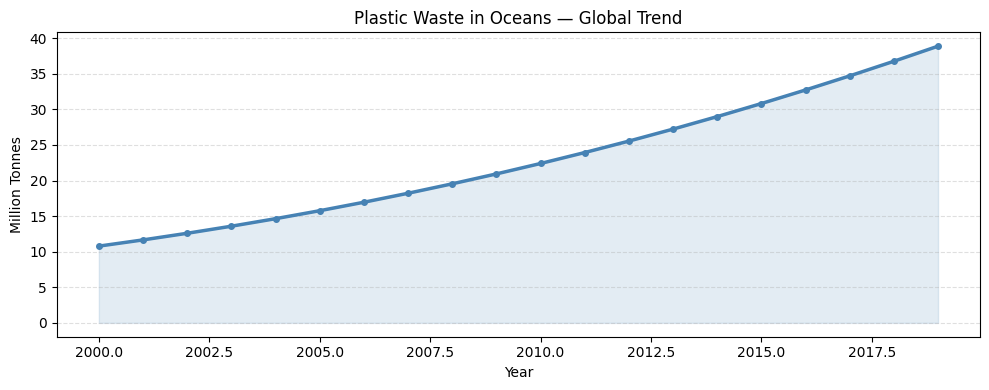

Saved → ..\Data\Clean\ocean_plastic.parquet  (5.5 KB, 80 rows)
✅ Dataset 5 saved


In [ ]:
# ── 6: Dataset 5 — ocean_plastic ────────────────────────
ocean_plastic_countries, ocean_plastic_regions = clean_ocean_plastic(
    Path(config["input_data"]["file5"])
)
# check the trend
plot_global_ocean_trend(ocean_plastic_regions, ocean_plastic_countries)
 
# Save
save_clean_parquet(
    ocean_plastic_countries,
    Path(config["output_data"]["file5"])
)
print("✅ Dataset 5 saved")

In [ ]:
# ── 7: Dataset 6 — plastic_generation ───────────────────
plastic_generation = clean_plastic_generation(config["input_data"]["file6"])
save_clean_parquet(
    plastic_generation,
    Path(config["output_data"]["file6"])
)
print("✅ Dataset 6 saved")

Exact duplicates: 0
Logical duplicates on ['country', 'year']: 0
Negative values: none ✅
Year range: 2010 – 2010, Countries: 168
Saved → ..\Data\Clean\plastic_generation.parquet  (8.9 KB, 168 rows)
✅ Dataset 6 saved


In [ ]:
# ── 8: Dataset 7 — plastic_vs_pollution ─────────────────
plastic_vs_pollution_countries, plastic_vs_pollution_regions = clean_plastic_vs_pollution(
    config["input_data"]["file7"]
)
save_clean_parquet(
    plastic_vs_pollution_countries,
    Path(config["output_data"]["file7"])
)
print("✅ Dataset 7 saved")

Exact duplicates: 0
Logical duplicates on ['country', 'year']: 0
Countries: 246 rows, 246 unique
Regions  : 7 rows
Saved → ..\Data\Clean\plastic_vs_pollution.parquet  (12.8 KB, 246 rows)
✅ Dataset 7 saved


In [ ]:
# ── 9: Dataset 8 — ocean_cleanup_efforts ────────────────
cleanup_efforts = build_cleanup_efforts()
 
# Also save raw CSV (for traceability)
cleanup_efforts.to_csv("../Data/Raw/ocean_cleanup_efforts.csv", index=False)
 
save_clean_parquet(
    cleanup_efforts,
    Path(config["output_data"]["file8"])
)
print("✅ Dataset 8 saved")

Shape: (25, 8)
Organisations: ['Ocean Conservancy (ICC)' 'The Ocean Cleanup']
Year range   : 2008 – 2025
Negative kg values: none ✅

Total kg removed per organisation:
organisation
Ocean Conservancy (ICC)    95,435,755 kg
The Ocean Cleanup          28,000,000 kg
Saved → ..\Data\Clean\ocean_cleanup_efforts.parquet  (6.2 KB, 25 rows)
✅ Dataset 8 saved


In [ ]:
# ── 10: Dataset 8b — top50 rivers from PDF ──────────────
df_rivers = parse_rivers_from_pdf("../Data/Raw/aaz5803_sm.pdf")
df_rivers.to_parquet(config["output_data"]["file4"], index=False)
print("✅ Dataset 8b (top50 rivers) saved")

Shape: (50, 4)
✅ Dataset 8b (top50 rivers) saved


In [ ]:
# ── 11: Quick sanity check — reload and preview all ─────
print("\n--- Sanity check: reloading all clean files ---")
for key, path in config["output_data"].items():
    try:
        df = pd.read_parquet(path)
        print(f"✅ {key}: {df.shape[0]:,} rows × {df.shape[1]} cols  →  {path}")
    except Exception as e:
        print(f"❌ {key}: {e}")


--- Sanity check: reloading all clean files ---
✅ file1: 31,819 rows × 4 cols  →  ../Data/Clean/rivers_with_countries.parquet
✅ file2: 57,387 rows × 5 cols  →  ../Data/Clean/plastic_adrift.parquet
✅ file3: 22,530 rows × 14 cols  →  ../Data/Clean/marine_microplastics.parquet
✅ file4: 50 rows × 4 cols  →  ../Data/Clean/top50_rivers_ranked.parquet
✅ file5: 80 rows × 6 cols  →  ../Data/Clean/ocean_plastic.parquet
✅ file6: 168 rows × 5 cols  →  ../Data/Clean/plastic_generation.parquet
✅ file7: 246 rows × 6 cols  →  ../Data/Clean/plastic_vs_pollution.parquet
✅ file8: 25 rows × 8 cols  →  ../Data/Clean/ocean_cleanup_efforts.parquet
